# Asymmetric Qubitization Resource Estimates

This notebook reads the resource estimtes for the different components of asymmetric qubitization and generates plots fitting the empirical results. 

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

df = pd.read_csv("re_data/t_gates.csv", skipinitialspace=True)

# Extract N (System Size) 
N_arr = df.loc[df["oracle"] == "A", "N"].to_numpy()

# Extract T-gate counts for each oracle type
T_A = df.loc[df["oracle"] == "A", "T"].to_numpy()
T_B = df.loc[df["oracle"] == "B", "T"].to_numpy()
T_U = df.loc[df["oracle"] == "U", "T"].to_numpy()

<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\l'
<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:73: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:62: SyntaxWarning: invalid escape sequence '\l'
<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:73: SyntaxWarning: invalid escape sequence '\m'
/var/folders/sk/07gyh_wd1cb_h1jzc9mntfjr0000gn/T/ipykernel_1795/2549194826.py:30: SyntaxWarning: invalid escape sequence '\l'
  label=f"Fit: {popt_A[0]:.0f} + {popt_A[1]:.0f} $\log^{{{popt_A[2]:.2f}}} N$")
/var/folders/sk/07gyh_wd1cb_h1jzc9mntfjr0000gn/T/ipykernel_1795/2549194826.py:33: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_title("Oracle A: $\mathcal{O}(\\text{polylog}(N/\\epsilon))$ \n ${ }_{(log\\mathtt{-}log \ scaling)}$", fontweight="bold")
/var/folders/sk/07gyh

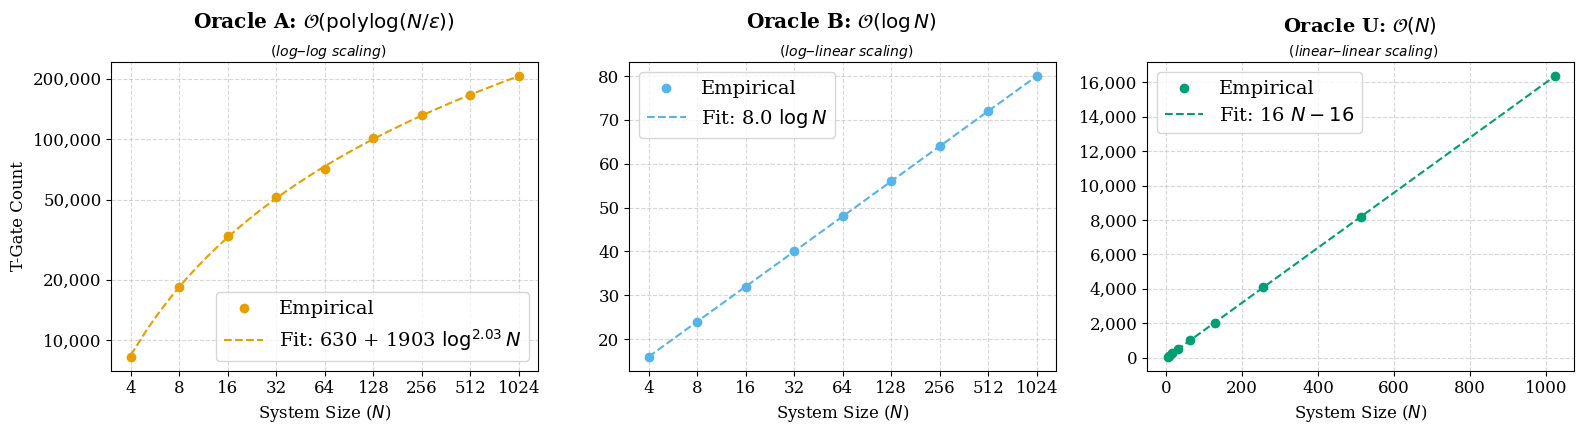

In [6]:
# Define dense N points for smooth theoretical curves
N_dense = np.linspace(4, 1024, 1000)

# 2. Define Fitting Functions
def polylog_model(N, c1, c2, p):
    return c1 + c2 * (np.log2(N) ** p)


def log_model(N, c1, c2):
    return c1 + c2 * np.log2(N)


def linear_model(N, m, b):
    return m * N + b


# Fit the empirical data to the models
popt_A, _ = curve_fit(polylog_model, N_arr, T_A, p0=[1000, 1000, 2])
popt_B, _ = curve_fit(log_model, N_arr, T_B)
popt_U, _ = curve_fit(linear_model, N_arr, T_U)

# Plotting configuration
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = {"A": "#E69F00", "B": "#56B4E9", "U": "#009E73"}

# --- Panel 1: Oracle A (Polylogarithmic) ---
axes[0].scatter(N_arr, T_A, color=colors["A"], zorder=5, label="Empirical")
axes[0].plot(N_dense, polylog_model(N_dense, *popt_A), "--", color=colors["A"],
             label=f"Fit: {popt_A[0]:.0f} + {popt_A[1]:.0f} $\log^{{{popt_A[2]:.2f}}} N$")
axes[0].set_xscale("log", base=2)
axes[0].set_yscale("log", base=10)
axes[0].set_title("Oracle A: $\mathcal{O}(\\text{polylog}(N/\\epsilon))$ \n ${ }_{(log\\mathtt{-}log \ scaling)}$", fontweight="bold")
axes[0].set_ylabel("T-Gate Count")


# 1. Tell the log engine exactly where to place gridlines
explicit_y_ticks = [10000, 20000, 50000, 100000, 200000]
axes[0].yaxis.set_major_locator(ticker.FixedLocator(explicit_y_ticks))

# 2. Use a dynamic function formatter to render beautiful math strings cleanly
def log_label_formatter(x, pos):
    if x == 10000: return r"$10^4$"
    if x == 100000: return r"$10^5$"
    # For intermediate ticks, format as matching scientific script (e.g., 2x10^4)
    exponent = int(np.log10(x))
    coeff = int(round(x / (10**exponent)))
    return f"${coeff} \\times 10^{exponent}$"

# axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(log_label_formatter))
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))

# 3. Completely nuke the minor locators so they can't cause conflicting text layers
axes[0].yaxis.set_minor_locator(ticker.NullLocator())
axes[0].yaxis.set_minor_formatter(ticker.NullFormatter())

axes[0].legend(loc="lower right", fontsize=14)

# --- Panel 2: Oracle B (Logarithmic - Consistent Legend) ---
axes[1].scatter(N_arr, T_B, color=colors["B"], zorder=5, label="Empirical")
axes[1].plot(N_dense, log_model(N_dense, *popt_B), "--", color=colors["B"],
             label=f"Fit: {popt_B[1]:.1f} $\log N$")# {popt_B[0]:+.1f}")
axes[1].set_xscale("log", base=2)
axes[1].set_title("Oracle B: $\mathcal{O}(\\log N)$ \n ${ }_{(log\\mathtt{-}linear \ scaling)}$", fontweight="bold")
axes[1].legend(loc="upper left", fontsize=14)

# --- Panel 3: Oracle U (Linear - Consistent Legend) ---
axes[2].scatter(N_arr, T_U, color=colors["U"], zorder=5, label="Empirical")
axes[2].plot(N_dense, linear_model(N_dense, *popt_U), "--", color=colors["U"],
             label=f"Fit: {popt_U[0]:.0f} $N - 16$")# {popt_U[1]:+.0f}")
axes[2].set_xscale("linear")
axes[2].set_xlim(-50, 1074)
axes[2].set_title("Oracle U: $\mathcal{O}(N)$ \n ${ }_{(linear\\mathtt{-}linear \ scaling)}$", fontsize=14, fontweight="bold")
axes[2].legend(loc="upper left", fontsize=14)

# Global formatting
for i, ax in enumerate(axes):
    ax.set_xlabel("System Size ($N$)")
    ax.grid(True, linestyle="--", alpha=0.5)
    if i < 2:
        ax.set_xticks(N_arr)
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

axes[2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))
plt.tight_layout()
plt.show()